# Problem 1: Linear Regression Model Estimation

Estimate the following linear model:

**y = 1 · X − 1 + ε**

where `X ∈ R^(60×1)` consists of generated values from -3 to 3 and `ε` obeys a normal distribution with mean 0 and standard deviation of 0.1.

Train the linear regression model as follows:

- set the weights and bias to 1;
- set the batch size to 10;
- **implement** the mean squared error loss;
- **implement** the mini-batch gradient descent optimizer, `lr = 0.05` (do not use the `torch.optim` package);
- set the total number of iterations to 25;

After the model is trained, compare the learned model parameters with the actual parameters.


In [1]:
import torch
import matplotlib.pyplot as plt
import numpy as np

lower_bound = -3
upper_bound = 3
learning_rate = 0.05
epsilon_mean = 0
epsilon_std = 0.1
num_examples = 60
num_epochs = 25
batch_size = 10

torch.manual_seed(42)
np.random.seed(42)

In [2]:
def synthetic_data(w, b, num_examples):
    """Generate y = Xw + b + noise."""
    X = torch.linspace(lower_bound, upper_bound, num_examples).reshape(-1, len(w))
    y = X @ w + b
    y += torch.normal(epsilon_mean, epsilon_std, y.shape)
    return X, y.reshape(-1, 1)

In [3]:
true_weights = torch.tensor([1.0])
true_bias = -1.0
features, labels = synthetic_data(true_weights, true_bias, num_examples)
print("Features:", features[0], "\nLabel:", labels[0])

Features: tensor([-3.]) 
Label: tensor([-3.8073])


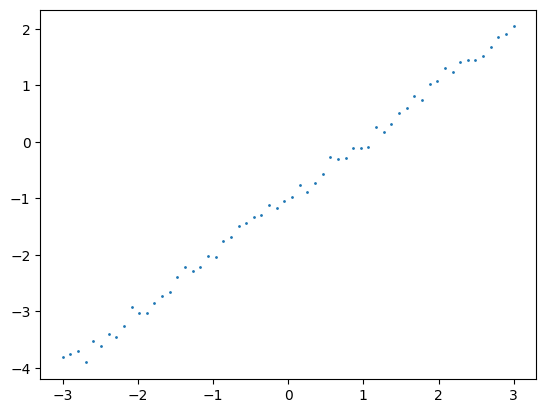

In [4]:
plt.scatter(features.detach().numpy(), labels.detach().numpy(), s=1)
plt.show()

In [5]:
def data_iter(batch_size, features, labels):
    num_examples = len(features)
    indices = list(range(num_examples))
    # The examples are read at random, in no particular order
    np.random.shuffle(indices)
    for i in range(0, num_examples, batch_size):
        batch_indices = torch.tensor(indices[i : min(i + batch_size, num_examples)])
        yield features[batch_indices], labels[batch_indices]

In [6]:
def load_array(data_arrays, batch_size, is_train=True):
    """Construct a PyTorch data iterator."""
    dataset = torch.utils.data.TensorDataset(*data_arrays)
    return torch.utils.data.DataLoader(dataset, batch_size, shuffle=is_train)

In [7]:
for X, y in data_iter(batch_size, features, labels):
    print(X, "\n", y)
    break

data_iter = load_array((features, labels), batch_size)

tensor([[-3.0000],
        [-2.4915],
        [ 0.6610],
        [ 1.5763],
        [-1.6780],
        [ 2.4915],
        [ 0.3559],
        [ 1.8814],
        [-1.7797],
        [ 2.7966]]) 
 tensor([[-3.8073],
        [-3.6150],
        [-0.3071],
        [ 0.5938],
        [-2.7339],
        [ 1.4463],
        [-0.7312],
        [ 1.0259],
        [-2.8524],
        [ 1.8490]])


In [8]:
# `nn` is an abbreviation for neural networks
from torch import nn

net = nn.Sequential(nn.Linear(1, 1))
net[0].weight.data.fill_(1.0)
net[0].bias.data.fill_(1.0)

tensor([1.])

In [9]:
def mse_loss(y_hat, y):
    return ((y_hat - y) ** 2).mean()


for epoch in range(num_epochs):
    for X, y in data_iter:
        l = mse_loss(net(X), y)
        # optimizer.zero_grad()
        for param in net.parameters():
            if param.grad is not None:
                param.grad.zero_()
        l.backward()
        # optimizer.step()
        for param in net.parameters():
            param.data -= param.grad * learning_rate

    l = mse_loss(net(features), labels)
    print(f"Epoch {epoch + 1}, Loss {l:f}")

Epoch 1, Loss 1.122493
Epoch 2, Loss 0.314530
Epoch 3, Loss 0.096298
Epoch 4, Loss 0.033837
Epoch 5, Loss 0.016760
Epoch 6, Loss 0.012033
Epoch 7, Loss 0.010433
Epoch 8, Loss 0.010241
Epoch 9, Loss 0.010094
Epoch 10, Loss 0.009962
Epoch 11, Loss 0.009963
Epoch 12, Loss 0.009995
Epoch 13, Loss 0.009969
Epoch 14, Loss 0.009957
Epoch 15, Loss 0.009978
Epoch 16, Loss 0.009973
Epoch 17, Loss 0.010053
Epoch 18, Loss 0.009989
Epoch 19, Loss 0.009954
Epoch 20, Loss 0.009945
Epoch 21, Loss 0.009943
Epoch 22, Loss 0.010010
Epoch 23, Loss 0.009945
Epoch 24, Loss 0.009950
Epoch 25, Loss 0.009997


In [10]:
w = net[0].weight.data
print("Error in estimating w:", true_weights - w.reshape(true_weights.shape))
b = net[0].bias.data
print("Error in estimating b:", true_bias - b)

Error in estimating w: tensor([-0.0093])
Error in estimating b: tensor([-0.0176])


# Problem 2: Softmax Regression on MNIST

Implement the softmax regression model to classify images from the MNIST dataset (28 × 28 images of handwritten digits, 10 classes; labels are digits 0–9; 60,000 training images and 10,000 testing images) as follows:

- set the batch size to 100;
- the validation dataset consists of 30,000 images and the rest represents the training dataset;
- set the weights to 1;
- use the cross-entropy loss function;
- use mini-batch stochastic gradient descent with a learning rate of 0.15 as the optimization algorithm;
- set the number of epochs to 15;
- plot the accuracy for the training and validation sets;
- use the trained model to classify 20 images.

Evaluate the trained model on the test set.


In [11]:
import torchvision
from torchvision import transforms

# `ToTensor()` converts the image data from PIL type to 32-bit floating point
# tensors. It also divides all numbers by 255, so that all pixel values are between
# 0 and 1
trans = transforms.ToTensor()
mnist_train = torchvision.datasets.FashionMNIST(
    root="../data", train=True, transform=trans, download=True
)
mnist_test = torchvision.datasets.FashionMNIST(
    root="../data", train=False, transform=trans, download=True
)

print(len(mnist_train), len(mnist_test))

batch_size = 100
training_dataset_size = 30000
validation_dataset_size = 30000
testing_dataset_size = 10000
set_weigth = torch.tensor([1.0])
epochs = 15
learning_rate = 0.15

100%|██████████| 26.4M/26.4M [00:06<00:00, 4.21MB/s]
100%|██████████| 29.5k/29.5k [00:00<00:00, 87.9MB/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 48.4MB/s]
100%|██████████| 5.15k/5.15k [00:00<00:00, 11.9MB/s]

60000 10000


In [12]:
def get_fashion_mnist_labels(labels):
    """Return text labels for the Fashion-MNIST dataset."""
    text_labels = [
        "t-shirt",
        "trouser",
        "pullover",
        "dress",
        "coat",
        "sandal",
        "shirt",
        "sneaker",
        "bag",
        "ankle boot",
    ]
    return [text_labels[int(i)] for i in labels]

In [13]:
def show_images(imgs, num_rows, num_cols, titles=None, scale=1.5):
    """Plot a list of images."""
    figsize = (num_cols * scale, num_rows * scale)
    _, axes = plt.subplots(num_rows, num_cols, figsize=figsize)
    plt.tight_layout()
    axes = axes.flatten()
    for i, (ax, img) in enumerate(zip(axes, imgs)):
        if torch.is_tensor(img):
            # Tensor Image
            ax.imshow(img.numpy())
        else:
            # PIL Image
            ax.imshow(img)
        ax.axes.get_xaxis().set_visible(False)
        ax.axes.get_yaxis().set_visible(False)
        if titles:
            ax.set_title(titles[i])
    return axes

array([<Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'dress'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'pullover'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 't-shirt'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sandal'}>,
       <Axes: title={'center': 'sneaker'}>,
       <Axes: title={'center': 'ankle boot'}>,
       <Axes: title={'center': 'trouser'}>,
       <Axes: title={'center': 't-shirt'}>], dtype=object)

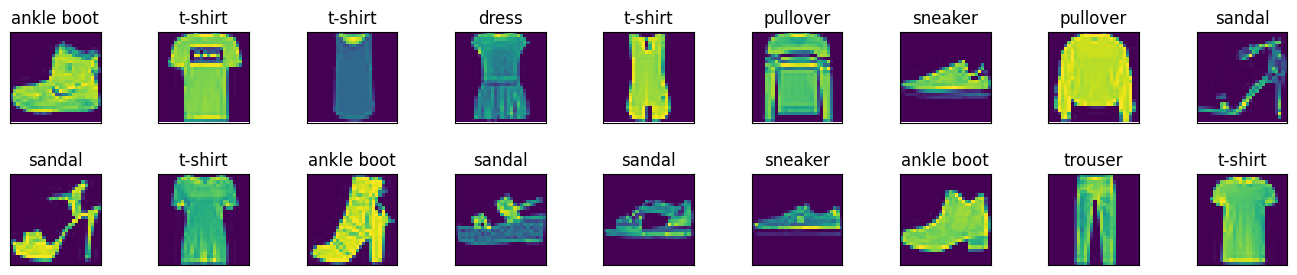

In [14]:
X, y = next(iter(torch.utils.data.DataLoader(mnist_train, batch_size=18)))
show_images(X.reshape(18, 28, 28), 2, 9, titles=get_fashion_mnist_labels(y))

In [15]:
# Use 2 processes to read the data.
train_iter = torch.utils.data.DataLoader(
    mnist_train, batch_size, shuffle=True, num_workers=2
)

In [16]:
def load_data_fashion_mnist(
    training_dataset_size, validation_dataset_size, batch_size, resize=None
):
    """Download the Fashion-MNIST dataset and then load it into memory."""
    trans = [transforms.ToTensor()]
    if resize:
        trans.insert(0, transforms.Resize(resize))
    trans = transforms.Compose(trans)
    mnist_train = torchvision.datasets.FashionMNIST(
        root="../data", train=True, transform=trans, download=True
    )
    mnist_test = torchvision.datasets.FashionMNIST(
        root="../data", train=False, transform=trans, download=True
    )
    mnist_train, mnist_val = torch.utils.data.random_split(
        mnist_train,
        [training_dataset_size, validation_dataset_size],
        generator=torch.Generator().manual_seed(42),
    )
    return (
        torch.utils.data.DataLoader(
            mnist_train, batch_size, shuffle=True, num_workers=2
        ),
        torch.utils.data.DataLoader(
            mnist_val, batch_size, shuffle=False, num_workers=2
        ),
        torch.utils.data.DataLoader(
            mnist_test, batch_size, shuffle=False, num_workers=2
        ),
    )


train_iter, val_iter, test_iter = load_data_fashion_mnist(
    training_dataset_size, validation_dataset_size, batch_size
)

In [17]:
# PyTorch does not implicitly reshape the inputs. Thus, we define the flatten
# layer to reshape the inputs before the linear layer in our network.
net = nn.Sequential(nn.Flatten(), nn.Linear(784, 10))


def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.ones_(set_weigth)


net.apply(init_weights)
loss = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(net.parameters(), lr=learning_rate)

In [18]:
def evaluate_accuracy(net, data_iter):
    """Compute the accuracy for a model on a dataset."""
    net.eval()  # Set the model to evaluation mode

    total_loss = 0
    total_hits = 0
    total_samples = 0
    with torch.no_grad():
        for X, y in data_iter:
            y_hat = net(X)
            l = loss(y_hat, y)
            total_loss += float(l)
            total_hits += sum(net(X).argmax(axis=1).type(y.dtype) == y)
            total_samples += y.numel()
    return float(total_loss) / len(data_iter), float(total_hits) / total_samples * 100

In [19]:
def train_epoch(net, train_iter, loss, optimizer):
    # Set the model to training mode
    net.train()
    # Sum of training loss, sum of training correct predictions, no. of examples
    total_loss = 0
    total_hits = 0
    total_samples = 0
    for X, y in train_iter:
        # Compute gradients and update parameters
        y_hat = net(X)
        l = loss(y_hat, y)
        # Using PyTorch built-in optimizer & loss criterion
        optimizer.zero_grad()
        l.backward()
        optimizer.step()
        total_loss += float(l)
        total_hits += sum(y_hat.argmax(axis=1).type(y.dtype) == y)
        total_samples += y.numel()
    # Return training loss and training accuracy
    return float(total_loss) / len(train_iter), float(total_hits) / total_samples * 100

In [20]:
def train(net, train_iter, val_iter, loss, num_epochs, optimizer):
    """Train a model."""
    train_loss_all = []
    train_acc_all = []
    val_loss_all = []
    val_acc_all = []
    for epoch in range(num_epochs):
        train_loss, train_acc = train_epoch(net, train_iter, loss, optimizer)
        train_loss_all.append(train_loss)
        train_acc_all.append(train_acc)
        val_loss, val_acc = evaluate_accuracy(net, val_iter)
        val_loss_all.append(val_loss)
        val_acc_all.append(val_acc)
        print(
            f"Epoch {epoch + 1}, Train loss {train_loss:.2f}, Train accuracy {train_acc:.2f}, Validation loss {val_loss:.2f}, Validation accuracy {val_acc:.2f}"
        )

    return train_loss_all, train_acc_all, val_loss_all, val_acc_all

In [21]:
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(
    net, train_iter, val_iter, loss, epochs, optimizer
)

/var/folders/14/2swb_m_965n1mt5_3k_btqt00000gn/T/ipykernel_96263/3204225458.py:16: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  total_loss += float(l)


Epoch 1, Train loss 0.77, Train accuracy 74.82, Validation loss 0.56, Validation accuracy 81.38
Epoch 2, Train loss 0.55, Train accuracy 81.38, Validation loss 0.52, Validation accuracy 81.85
Epoch 3, Train loss 0.51, Train accuracy 82.72, Validation loss 0.52, Validation accuracy 82.64
Epoch 4, Train loss 0.49, Train accuracy 83.17, Validation loss 0.49, Validation accuracy 83.26
Epoch 5, Train loss 0.47, Train accuracy 83.85, Validation loss 0.47, Validation accuracy 83.88
Epoch 6, Train loss 0.46, Train accuracy 84.25, Validation loss 0.52, Validation accuracy 82.51
Epoch 7, Train loss 0.45, Train accuracy 84.44, Validation loss 0.46, Validation accuracy 84.32
Epoch 8, Train loss 0.45, Train accuracy 84.81, Validation loss 0.48, Validation accuracy 83.91
Epoch 9, Train loss 0.44, Train accuracy 84.76, Validation loss 0.48, Validation accuracy 82.91
Epoch 10, Train loss 0.44, Train accuracy 85.09, Validation loss 0.60, Validation accuracy 78.73
Epoch 11, Train loss 0.43, Train accura

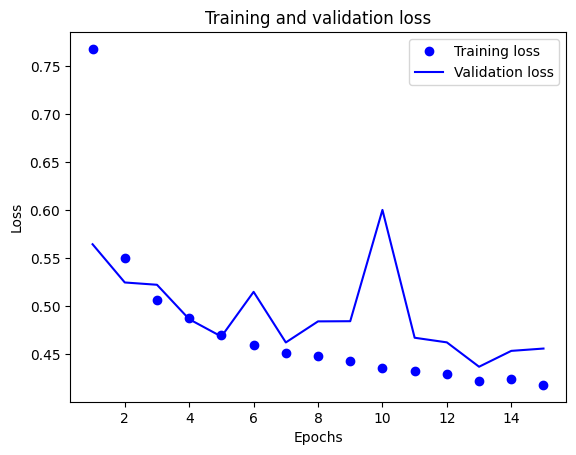

In [22]:
def plot_loss(train_loss_all, val_loss_all):
    epochs = range(1, len(train_loss_all) + 1)
    plt.plot(epochs, train_loss_all, "bo", label="Training loss")
    plt.plot(epochs, val_loss_all, "b", label="Validation loss")
    plt.title("Training and validation loss")
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()


plot_loss(train_loss_all, val_loss_all)

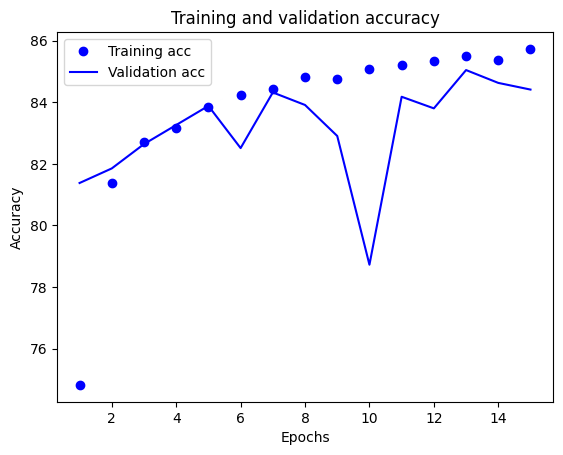

In [23]:
def plot_accuracy(train_acc_all, val_acc_all):
    epochs = range(1, len(train_acc_all) + 1)
    plt.plot(epochs, train_acc_all, "bo", label="Training acc")
    plt.plot(epochs, val_acc_all, "b", label="Validation acc")
    plt.title("Training and validation accuracy")
    plt.xlabel("Epochs")
    plt.ylabel("Accuracy")
    plt.legend()
    plt.show()


plot_accuracy(train_acc_all, val_acc_all)

In [24]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f"Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}")

Test loss 0.48, Test accuracy 83.61


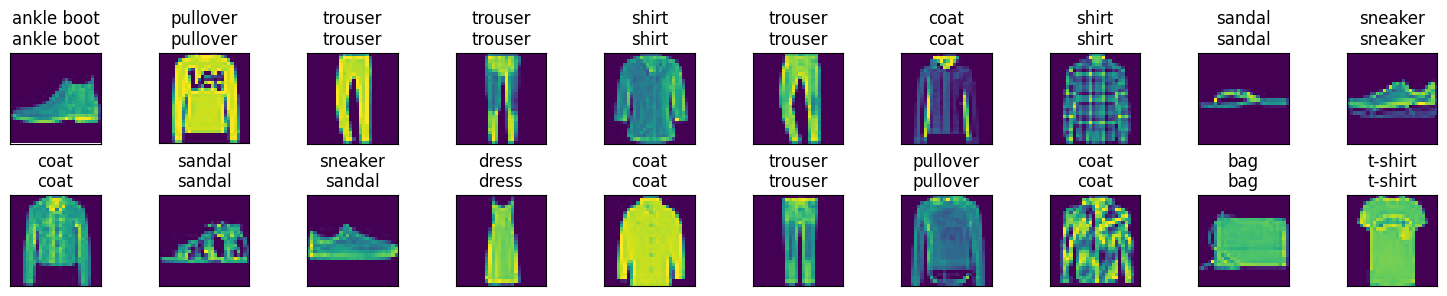

In [25]:
def predict(net, test_iter, n=20):
    """Predict labels."""
    for X, y in test_iter:
        break
    trues = get_fashion_mnist_labels(y)
    preds = get_fashion_mnist_labels(net(X).argmax(axis=1))
    titles = [true + "\n" + pred for true, pred in zip(trues, preds)]
    show_images(X[0:n].reshape((n, 28, 28)), 2, int(n / 2), titles=titles[0:n])


predict(net, test_iter)

# Problem 3: MLP for MNIST Classification

Classify the MNIST dataset (28 × 28 images, 10 classes, 60,000 training images and 10,000 testing images) using an MLP as follows:

- two hidden layers with 256 units;
- add the hyperbolic tangent activation function and a dropout layer after each hidden layer (dropout probability of 40%);
- use 45,000 training images and 15,000 validation images;
- use the cross-entropy loss function;
- apply Xavier initialization to the weights and set the biases to zero;
- set the batch size to 512 and the learning rate to 0.15;
- train the model for 10 epochs.

Evaluate the trained model on the test set.


In [26]:
hidden_layer_units = 256
dropout = 0.4
training_dataset_size = 45000
validation_dataset_size = 15000
learning_rate = 0.15
epochs = 10

net = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, hidden_layer_units),
    # Add a hyperbolic tangent activation function after the first fully connected layer
    nn.Tanh(),
    # Add a dropout layer after the first fully connected layer
    nn.Dropout(dropout),
    nn.Linear(hidden_layer_units, hidden_layer_units),
    # Add a hyperbolic tangent activation function after the second fully connected layer
    nn.Tanh(),
    # Add a dropout layer after the second fully connected layer
    nn.Dropout(dropout),
    nn.Linear(hidden_layer_units, 10),
)


def init_weights(m):
    if type(m) == nn.Linear:
        nn.init.xavier_uniform_(m.weight)
        nn.init.zeros_(m.bias)


net.apply(init_weights)

Sequential(
  (0): Flatten(start_dim=1, end_dim=-1)
  (1): Linear(in_features=784, out_features=256, bias=True)
  (2): Tanh()
  (3): Dropout(p=0.4, inplace=False)
  (4): Linear(in_features=256, out_features=256, bias=True)
  (5): Tanh()
  (6): Dropout(p=0.4, inplace=False)
  (7): Linear(in_features=256, out_features=10, bias=True)
)

In [27]:
train_iter, val_iter, test_iter = load_data_fashion_mnist(
    training_dataset_size, validation_dataset_size, batch_size
)

In [28]:
optimizer = torch.optim.SGD(net.parameters(), lr=learning_rate)
train_loss_all, train_acc_all, val_loss_all, val_acc_all = train(
    net, train_iter, val_iter, loss, epochs, optimizer
)

Epoch 1, Train loss 0.68, Train accuracy 75.38, Validation loss 0.63, Validation accuracy 75.25
Epoch 2, Train loss 0.53, Train accuracy 81.05, Validation loss 0.48, Validation accuracy 82.28
Epoch 3, Train loss 0.49, Train accuracy 82.42, Validation loss 0.44, Validation accuracy 84.22
Epoch 4, Train loss 0.47, Train accuracy 82.87, Validation loss 0.46, Validation accuracy 83.65
Epoch 5, Train loss 0.46, Train accuracy 83.76, Validation loss 0.45, Validation accuracy 84.58
Epoch 6, Train loss 0.44, Train accuracy 83.97, Validation loss 0.40, Validation accuracy 85.35
Epoch 7, Train loss 0.44, Train accuracy 84.23, Validation loss 0.41, Validation accuracy 85.36
Epoch 8, Train loss 0.43, Train accuracy 84.48, Validation loss 0.40, Validation accuracy 85.54
Epoch 9, Train loss 0.42, Train accuracy 84.77, Validation loss 0.41, Validation accuracy 85.30
Epoch 10, Train loss 0.41, Train accuracy 84.80, Validation loss 0.39, Validation accuracy 85.81


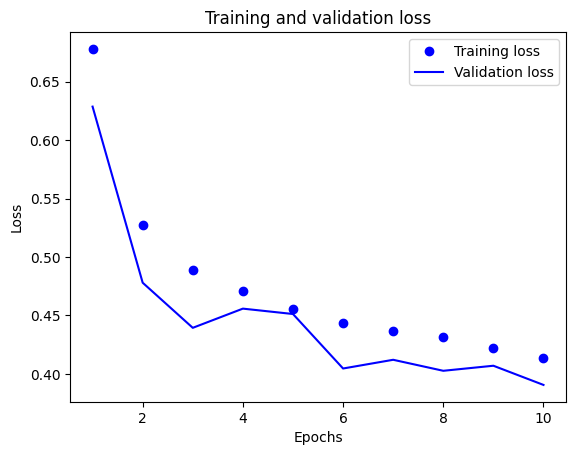

In [29]:
plot_loss(train_loss_all, val_loss_all)

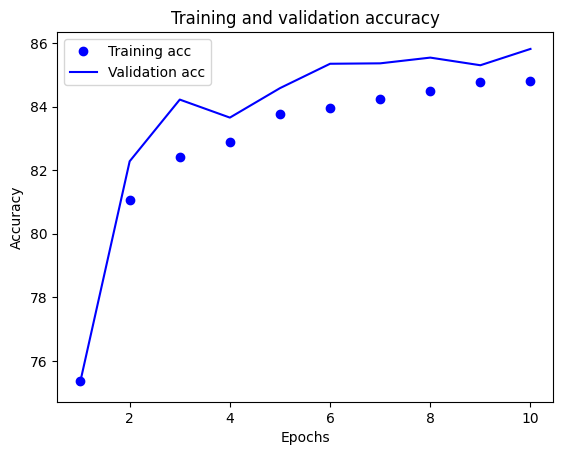

In [30]:
plot_accuracy(train_acc_all, val_acc_all)

In [31]:
test_loss, test_acc = evaluate_accuracy(net, test_iter)
print(f"Test loss {test_loss:.2f}, Test accuracy {test_acc:.2f}")

Test loss 0.41, Test accuracy 84.99
